The plan for this file it to have all the code to go from the different planet spectra to them making a new planet list hopefully in an organsied way so it can all be done from one file. 


This code is a combination of code writen by Archie, Abi and Tamzin. The code was put into one document by Miles but he did not write the original code. 

In [ ]:
#--- Imports ---#
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from pathlib import Path
import emcee
import corner as corner
from emcee.moves import DEMove, DESnookerMove
from concurrent.futures import ProcessPoolExecutor
import os
from prettytable import PrettyTable

class Statistics:
    """Handles all statistical analysis, MCMC fitting, and visualization."""
    
   
    def __init__(self, nwalkers=64,use_parallel=True, n_cores=None):
        self.nwalkers = nwalkers
        self.use_parallel = use_parallel
        
        if n_cores is None:
            cores = os.cpu_count()
            if cores is not None and cores > 8:
                self.n_cores = 8
            else: 
                self.n_cores = cores
        else:
            self.n_cores = n_cores
        
    
    @staticmethod
    def polynomial_model( x_axis, theta):
        """Vectorized polynomial model."""
        return np.polyval(theta, x_axis)
    
    @staticmethod
    def log_likelihood(theta, x_axis, y_axis, y_axis_err, xerr=None):
        """
        Log-likelihood accounting for uncertainties on both x and y.
        
        Parameters:
        -----------
        theta : array
            Model parameters
        x, y : arrays
            Data
        yerr : array
            Uncertainty on y (feature height)
        xerr : array or None
            Uncertainty on x (temperature). If None, ignored.
            """
        
        model = Statistics.polynomial_model(x_axis, theta)
        diff  = y_axis - model

        if xerr is not None:
            # Compute dy/dx (gradient of model w.r.t. x)
            # Works for any polynomial degree
            ndim = len(theta)

            if ndim == 3:
                # Quadratic: dy/dx = 2A*x + B
                dydx = 2 * theta[0] * x_axis + theta[1]

            elif ndim == 2:
                # Linear: dy/dx = B (constant)
                dydx = np.full_like(x_axis, theta[0])

            else:
                # General polynomial: use numpy gradient of coefficients
                # derivative of a_n*x^n + ... is n*a_n*x^(n-1) + ...
                deriv_coeffs = np.polyder(theta)
                dydx = np.polyval(deriv_coeffs, x_axis)

            # Effective variance: σ_eff² = σ_y² + (dy/dx)² * σ_x²
            sigma_eff2 = y_axis_err**2 + (dydx * xerr)**2

        else:
            # No x uncertainty - original behaviour
            sigma_eff2 = y_axis_err**2

        # Log-likelihood with effective variance
        chi2    = np.sum(diff**2 / sigma_eff2)
        log_det = np.sum(np.log(2 * np.pi * sigma_eff2))

        return -0.5 * (chi2 + log_det)
    
    @staticmethod
    def log_prior(theta, priors):
        """Vectorized prior check."""
        for param, (low, high) in zip(theta, priors):
            if not (low < param < high):
                return -np.inf
        return 0.0
    
    @staticmethod
    def log_probability(theta, x_axis, y_axis, y_axis_err, priors, xerr=None):
        """Combined log-posterior with optional x uncertainty."""
        lp = Statistics.log_prior(theta, priors)
        if not np.isfinite(lp):
            return -np.inf
        return lp + Statistics.log_likelihood(theta, x_axis, y_axis, y_axis_err, xerr)
    
    
    @staticmethod
    def get_smart_scaling(x_axis, y_axis):
        """

        This centures the x axis arround the mean of the data, and scales both x and y to their
        maximum absolute values. This helps to improve the numerical stability of the MCMC sampling, 
        especially for polynomial models where parameters can have vastly different scales.
        """
        # Scale to characteristic values (not mean/std)
        x_scale = np.abs(x_axis).max()  # Characteristic temperature
        y_scale = np.abs(y_axis).max()  # Characteristic feature height
        
        return x_scale, y_scale
    
    @staticmethod
    def scale_priors(priors, x_scale):
        """
        Scale priors to match scaled coordinates.
        For quadratic: A gets scaled by x_scale^2, B by x_scale
        """
        scaled_priors = []
        n_params = len(priors)
        
        if n_params == 3:  # Quadratic: [A, B, C]
            A_low, A_high = priors[0]
            B_low, B_high = priors[1]
            C_low, C_high = priors[2]
            
            scaled_priors = [
                (A_low * x_scale**2, A_high * x_scale**2),  # A scales by x^2
                (B_low * x_scale, B_high * x_scale),         # B scales by x
                (C_low, C_high)                              # C unchanged
            ]
        elif n_params == 2:  # Linear: [B, C]
            B_low, B_high = priors[0]
            C_low, C_high = priors[1]
            
            scaled_priors = [
                (B_low * x_scale, B_high * x_scale),  # B scales by x
                (C_low, C_high)                       # C unchanged
            ]
        
        return scaled_priors
    
    @staticmethod
    def unscale_samples(samples, x_scale, n_params):
        """Transform samples back to original scale."""
        unscaled = samples.copy()
        
        if n_params == 3:  # Quadratic
            unscaled[:, 0] = samples[:, 0] / (x_scale**2)  # A
            unscaled[:, 1] = samples[:, 1] / x_scale        # B
            # C unchanged
        elif n_params == 2:  # Linear
            unscaled[:, 0] = samples[:, 0] / x_scale  # B
            # C unchanged
        
        return unscaled
     
    @staticmethod
    def calculate_bic(log_likelihood, n_params, n_data):
        """Calculate Bayesian Information Criterion."""
        return n_params * np.log(n_data) - 2 * log_likelihood

    @staticmethod
    def calculate_chi_squared(y_data, y_model, yerr):
        """Calculate chi-squared statistic."""
        return np.sum(((y_data - y_model) / yerr)**2)
    
    @staticmethod
    def initialize(priors, nwalkers, x_data, y_data):
        """
        Initialize walkers using OLS fit as starting guess.
        Much faster convergence than random initialization.
        
        Parameters:
        -----------
        priors : list of tuples
            [(low, high), ...] bounds for each parameter
        nwalkers : int
            Number of MCMC walkers
        x_data : array
            Input data (scaled)
        y_data : array
            Output data
            
        Returns:
        --------
        pos : ndarray (nwalkers, ndim)
            Initial walker positions
        p_init : array
            Initial parameter guess from OLS
        """
        ndim = len(priors)
        
        # Quick least-squares fit for a good starting point
        if ndim == 3:
            p_init = np.polyfit(x_data, y_data, 2)   # Quadratic OLS
        elif ndim == 2:
            p_init = np.polyfit(x_data, y_data, 1)   # Linear OLS
        else:
            p_init = np.polyfit(x_data, y_data, ndim - 1)
        
        # If OLS guess falls outside priors, fall back to prior midpoint
        for i, (val, (low, high)) in enumerate(zip(p_init, priors)):
            if not (low < val < high):
                p_init[i] = 0.5 * (low + high)
        
        # Scatter walkers in a small ball around the OLS guess
        pos = np.zeros((nwalkers, ndim))
        for i, (low, high) in enumerate(priors):
            width = high - low
            pos[:, i] = p_init[i] + 0.01 * width * np.random.randn(nwalkers)
            # Clip to ensure all walkers stay within priors
            pos[:, i] = np.clip(pos[:, i], low + 1e-10, high - 1e-10)
        
        return pos, p_init
        
    def run_mcmc(self, x_data, y_data, y_data_err, priors,
                        xerr=None,              
                        nsteps=5000, burn=1000,
                        use_smart_scaling=True,
                        progress=True):
        """
        MCMC with optional x uncertainty support.
        """
        ndim = len(priors)

        # Smart scaling
        if use_smart_scaling:
            x_scale, y_scale = self.get_smart_scaling(x_data, y_data)
            x_fit = x_data / x_scale
            
            # Scale xerr too if provided
            xerr_fit = xerr / x_scale if xerr is not None else None
            
            priors_fit = self.scale_priors(priors, x_scale)
            
            if xerr is not None:
                print(f"✓ Including x uncertainties (mean xerr = {np.mean(xerr):.1f} K)")
                print(f"  Mean scaled xerr = {np.mean(xerr_fit):.4f}")
        else:
            x_fit    = x_data
            xerr_fit = xerr
            x_scale  = 1.0
            priors_fit = priors

        # Smart initialization
        pos, p_init = self.initialize(priors_fit, self.nwalkers, x_fit, y_data)

        # DE moves
        moves = [
            (DEMove(), 0.8),
            (DESnookerMove(), 0.15),
            (emcee.moves.StretchMove(), 0.05)
        ]

        # Create sampler - pass xerr through args
        sampler = emcee.EnsembleSampler(
            self.nwalkers,
            ndim,
            self.log_probability,
            args=(x_fit, y_data, y_data_err, priors_fit, xerr_fit),
            moves=moves,
        )

        # Burn-in
        print(f"\nRunning burn-in ({burn} steps)...")
        state = sampler.run_mcmc(pos, burn, progress=progress)
        sampler.reset()

        # Production
        print(f"Running production ({nsteps} steps)...")
        sampler.run_mcmc(state, nsteps, progress=progress)

        # Extract and unscale samples
        samples_fit = sampler.get_chain(flat=True)

        if use_smart_scaling:
            samples = self.unscale_samples(samples_fit, x_scale, ndim)
        else:
            samples = samples_fit

        tau = sampler.get_autocorr_time()

        print(f"\n✓ Sampling complete!")
        print(f"Autocorrelation time: {tau}")
        print(f"Effective samples: {len(samples) / np.max(tau):.0f}")

        return sampler, samples, tau
    
    @staticmethod
    def suggest_priors(T_data, y_data, model_type='quadratic', 
                      safety_factor=20):
        """Generate data-driven priors.This means that you don't have to put in new priors for each new data set"""
        T_min, T_max = T_data.min(), T_data.max()
        y_min, y_max = y_data.min(), y_data.max()
        T_range = T_max - T_min
        y_range = y_max - y_min
        T_mid = (T_min + T_max) / 2
        y_mid = (y_min + y_max) / 2
        
        if model_type == 'quadratic':
            A_estimate = y_range / (T_max - T_mid)**2
            B_estimate = y_range / T_range
            C_estimate = y_mid
            
            A_bound = safety_factor * max(abs(A_estimate), 1e-6)
            B_bound = safety_factor * max(abs(B_estimate), 1.0)
            C_bound = y_mid + safety_factor * y_range
            
            priors = [
                (-A_bound, A_bound),
                (-B_bound, B_bound),
                (-C_bound, C_bound)
            ]
            

            print("SUGGESTED PRIORS (Quadratic)")
            print(f"  A: [{priors[0][0]:.6e}, {priors[0][1]:.6e}]")
            print(f"  B: [{priors[1][0]:.3f}, {priors[1][1]:.3f}]")
            print(f"  C: [{priors[2][0]:.1f}, {priors[2][1]:.1f}]")

            
        else:  # linear
            B_estimate = y_range / T_range
            C_estimate = y_mid - B_estimate * T_mid
            
            B_bound = safety_factor * max(abs(B_estimate), 1.0)
            C_bound = abs(C_estimate) + safety_factor * y_range
            
            priors = [
                (-B_bound, B_bound),
                (-C_bound, C_bound)
            ]
            
            print("SUGGESTED PRIORS (Linear)")
            print(f"  B: [{priors[0][0]:.3f}, {priors[0][1]:.3f}]")
            print(f"  C: [{priors[1][0]:.1f}, {priors[1][1]:.1f}]")

        
        return priors
        
    @staticmethod
    def Mean_absolute_error(y_data, y_model_obs):
        """Calculate Mean Absolute Error."""
        residuals_quad = y_data - y_model_obs
        return 1/len(residuals_quad) * sum(np.abs(residuals_quad))

    @staticmethod
    def MS_Posterior_Predictive_Check(samples_quad, y_data, y_model_obs, x_data, y_data_err):
        residuals_quad = y_data - y_model_obs
        idx = np.random.choice(len(samples_quad), size=500, replace=False)

        rms_sim = []
        for i in idx:
            A, x0, ymin, log_sigma = samples_quad[i]
            sigma_int = np.exp(log_sigma)

            y_sim = (
                A * (x_data - x0)**2 + ymin
                + np.random.normal(0, y_data_err, size=len(x_data))
                + np.random.normal(0, sigma_int, size=len(x_data)))

            y_model_i = A * (x_data - x0)**2 + ymin
            rms_sim.append(np.sqrt(np.mean((y_sim - y_model_i)**2)))

        rms_obs = np.sqrt(np.mean(residuals_quad**2))
        rms_obs_minus_sim = rms_obs - np.mean(rms_sim)
        rms_z_score = rms_obs_minus_sim / np.std(rms_sim)
        return rms_sim, rms_obs, rms_z_score


    @staticmethod
    def curvature_stat(samples_quad, y_data, x, Y_err, rng=np.random.default_rng()):
        """
        RMS of second finite differences.
        Measures curvature independent of slope/offset.
        """
        T_curv_obs = np.sqrt(np.mean((y_data[2:] - 2*y_data[1:-1] + y_data[:-2])**2))
        T_curv_sim = []

        idx = np.random.choice(len(samples_quad), size=500, replace=False)

        for i in idx:
            A, x0, ymin, log_sigma = samples_quad[i]
            sigma_int = np.exp(log_sigma)

            y_model_i = A * (x - x0)**2 + ymin

            y_sim = (
                y_model_i
                + rng.normal(0, Y_err)
                + rng.normal(0, sigma_int, size=len(x))
            )

            T_curv_sim.append(np.sqrt(np.mean((y_sim[2:] - 2*y_sim[1:-1] + y_sim[:-2])**2)))

        T_curv_sim = np.array(T_curv_sim)

        curv_mean = np.mean(T_curv_sim)
        curv_std = np.std(T_curv_sim)
        curv_z = (T_curv_obs - curv_mean) / curv_std # less than or equal to 2 means shape is good

        print(f"\nCurvature PPC:")
        print(f"Simulated curvature = {curv_mean:.3f} ± {curv_std:.3f}")
        print(f"Observed curvature = {T_curv_obs:.3f}")
        print(f"Z-score = {curv_z:.3f}")
        return curv_mean, curv_std, curv_z, T_curv_obs, T_curv_sim


    @staticmethod
    def diagnose_fit(samples, T_data, y_data, yerr_data, model_func, 
                    model_name="Model", true_params=None):
        """
        Comprehensive diagnostics for MCMC fit quality.
        """

        print(f"DIAGNOSTIC: {model_name}")

        
        # Sample statistics
        median_params = np.median(samples, axis=0)
        std_params = np.std(samples, axis=0)
        
        param_names = ['A', 'B', 'C'] if len(median_params) == 3 else ['B', 'C']
        for i, name in enumerate(param_names):
            print(f"  {name}: {median_params[i]:.6e} ± {std_params[i]:.6e}")
        
        print(f"  Any NaN: {np.any(np.isnan(samples))}")
        print(f"  Any Inf: {np.any(np.isinf(samples))}")
        
        # Prediction check
        y_pred = model_func(median_params, T_data)
        residuals = y_data - y_pred
        chi2 = Statistics.calculate_chi_squared(y_data, y_pred, yerr_data)
        red_chi2 = chi2 / (len(y_data) - len(median_params))
        
        print(f"  Mean residual: {np.mean(residuals):.2f} ± {np.std(residuals):.2f}")

        
        # Compare to true values if provided
        if true_params is not None:
            print("\nComparison to True Values:")
            for i, name in enumerate(param_names):
                true_val = true_params[i]
                recovered = median_params[i]
                error = std_params[i]
                sigma_diff = abs(true_val - recovered) / error
                print(f"  {name}: True={true_val:.6e}, Recovered={recovered:.6e} ± {error:.6e}")
                print(f"      → Difference: {sigma_diff:.2f}σ {'✓' if sigma_diff < 3 else '⚠️'}")
        
        # Quality assessment
        print("\nQuality Assessment:")
        if red_chi2 < 0.5:
            print("  ⚠️  Reduced χ² < 0.5: May be overfitting or errors overestimated")
        elif red_chi2 > 2.0:
            print("  ⚠️  Reduced χ² > 2.0: Poor fit or errors underestimated")
        else:
            print("  ✓ Reduced χ² ≈ 1: Good fit!")
        
        if np.std(y_pred) < 1e-6:
            print("  ⚠️  Predictions are nearly constant - model may not be working")
        else:
            print("  ✓ Model produces varying predictions")
        
        print("=" * 70)
        
        return {
            'median_params': median_params,
            'std_params': std_params,
            'chi2': chi2,
            'red_chi2': red_chi2,
            'residuals': residuals
        }
    
    @staticmethod
    def make_corner_plot(sampler_or_samples, labels, burn=1000, thin=1,
                        title="Posterior", print_map=True, print_autocorr=True,
                        truths=None):
        """
        Create a corner plot from either:
        - An emcee sampler object, OR
        - A numpy array of samples directly
        """
        
        # ---- Handle both sampler and raw samples ----
        if isinstance(sampler_or_samples, np.ndarray):
            # Already a flat samples array - use directly
            flat_samples = sampler_or_samples
            flat_logprob = None
            print_autocorr = False  # Can't get autocorr without sampler
            print("(Received samples array directly)")
        else:
            # It's an emcee sampler object
            sampler = sampler_or_samples
            flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
            flat_logprob = sampler.get_log_prob(discard=burn, thin=thin, flat=True)

        # ---- Corner plot ----
        fig = corner.corner(
            flat_samples[:, :len(labels)],
            labels=labels,
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
            title_fmt=".4g",
            title_kwargs={"fontsize": 12},
            truths=truths
        )
        fig.suptitle(title, fontsize=14, y=1.00)
        plt.tight_layout()
        plt.show()

        # ---- MAP estimate (only if we have log probs) ----
        if print_map and flat_logprob is not None:
            imax = np.argmax(flat_logprob)
            theta_map = flat_samples[imax, :len(labels)]

   
            print("MAP (Maximum A Posteriori) Estimate:")

            for name, val in zip(labels, theta_map):
                print(f"  {name:15s} = {val:.6g}")

        elif print_map:
            # No log probs, use median instead
            theta_median = np.median(flat_samples[:, :len(labels)], axis=0)
            theta_std = np.std(flat_samples[:, :len(labels)], axis=0)


            print("Posterior Median Estimates:")

            for name, med, std in zip(labels, theta_median, theta_std):
                print(f"  {name:15s} = {med:.6g} ± {std:.6g}")


        # ---- Autocorrelation (only if we have sampler) ----
        if print_autocorr and not isinstance(sampler_or_samples, np.ndarray):
            try:
                tau = sampler_or_samples.get_autocorr_time()
                print(f"\nAutocorrelation time: {tau}")
            except Exception as e:
                print("Could not estimate autocorrelation time (chain may be too short).")

        return flat_samples, flat_logprob
    
    @staticmethod
    def plot_posterior_fits(x_data, y_data, yerr_data, samples, model_func,
                           title="Posterior Fits", n_draws=100, show_cloud=True):
        """
        IMPROVED: Plot data with posterior predictive distribution and credible intervals.
        """

        median_params = np.median(samples, axis=0)
        y_pred = model_func(median_params, x_data)
        residuals = y_data - y_pred
        chi2     = Statistics.calculate_chi_squared(y_data, y_pred, yerr_data)
        red_chi2 = chi2 / (len(y_data) - len(median_params))
        BIC      = Statistics.calculate_bic(-0.5 * chi2, samples.shape[1], len(y_data))
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), 
                                gridspec_kw={'height_ratios': [2, 1]})
        
        # Generate smooth grid for plotting
        T_plot = np.linspace(x_data.min() - 0.05*(x_data.max()-x_data.min()), 
                            x_data.max() + 0.05*(x_data.max()-x_data.min()), 300)
        
        # Calculate posterior predictions
        y_posterior = np.array([model_func(params, T_plot) for params in samples])
        
        # Plot credible intervals FIRST (so they're behind)
        y_median = np.median(y_posterior, axis=0)
        y_16 = np.percentile(y_posterior, 16, axis=0)
        y_84 = np.percentile(y_posterior, 84, axis=0)
        y_025 = np.percentile(y_posterior, 2.5, axis=0)
        y_975 = np.percentile(y_posterior, 97.5, axis=0)
        
        # 95% interval
        ax1.fill_between(T_plot, y_025, y_975, color='yellow', alpha=0.3, 
                       label='95% credible interval', zorder=1)
        # 68% interval
        ax1.fill_between(T_plot, y_16, y_84, color='orange', alpha=0.4, 
                       label='68% credible interval', zorder=2)
        
        # Plot posterior cloud (if requested)
        if show_cloud:
            idx = np.random.choice(len(samples), min(n_draws, len(samples)), replace=False)
            for i in idx:
                y_model = model_func(samples[i], T_plot)
                ax1.plot(T_plot, y_model, color='coral', alpha=0.05, lw=0.8, zorder=3)
        
        # Plot median fit (thick line on top)
        ax1.plot(T_plot, y_median, color='darkblue', lw=3, 
               label='Posterior median', zorder=10)
        
        # Plot data LAST (so it's on top)
        ax1.errorbar(x_data, y_data, yerr=yerr_data, fmt='o', color='black',
                   label='Data', markersize=8, capsize=4, elinewidth=2, 
                   markeredgecolor='white', markeredgewidth=1, zorder=15)
        
        # Add parameter info box
        median_params = np.median(samples, axis=0)
        std_params = np.std(samples, axis=0)
        
        param_text = "Posterior median ± σ:\n"
        if len(median_params) == 3:
            param_text += f"A = {median_params[0]:.4e} ± {std_params[0]:.2e}\n"
            param_text += f"B = {median_params[1]:.4e} ± {std_params[1]:.2e}\n"
            param_text += f"C = {median_params[2]:.2f} ± {std_params[2]:.2f}"
            param_text += f"\n\nχ² = {chi2:.2f}\nReduced χ² = {red_chi2:.3f}\nBIC = {BIC:.2f}"
        else:
            param_text += f"B = {median_params[0]:.4e} ± {std_params[0]:.2e}\n"
            param_text += f"C = {median_params[1]:.2f} ± {std_params[1]:.2f}"
            param_text += f"\n\nχ² = {chi2:.2f}\nReduced χ² = {red_chi2:.3f}\nBIC = {BIC:.2f}"
        
        ax1.text(0.02, 0.98, param_text, transform=ax1.transAxes,
               fontsize=12, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Formatting
        ax1.set_xlabel("Temperature (K)", fontsize=13, fontweight='bold')
        ax1.set_ylabel("Feature Height", fontsize=13, fontweight='bold')
        ax1.set_title(title, fontsize=15, fontweight='bold', pad=15)
        ax1.legend(fontsize=11, loc='best', framealpha=0.9)
        ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)
        
        y_data_pred = model_func(np.median(samples, axis=0), x_data)
        residuals = y_data - y_data_pred
        normalized_residuals = residuals / yerr_data


        ax2.axhline(0, color='blue', linestyle='--', lw=2, alpha=0.7, label='Zero')
        ax2.axhline(2, color='red', linestyle=':', lw=1.5, alpha=0.5)
        ax2.axhline(-2, color='red', linestyle=':', lw=1.5, alpha=0.5, label='±2σ')
        ax2.fill_between(x_data, -1, 1, color='green', alpha=0.15, label='±1σ')
        
        ax2.errorbar(x_data, normalized_residuals, yerr=1.0, fmt='o', color='black',
                    markersize=7, capsize=3, elinewidth=1.5)
        
        ax2.set_xlabel("Temperature (K)", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Normalized Residuals\n(Data - Model) / Error", fontsize=11, fontweight='bold')
        ax2.legend(fontsize=9, loc='best')
        ax2.grid(alpha=0.3, linestyle='--')

        mean_res = np.mean(normalized_residuals)
        std_res = np.std(normalized_residuals)
        stats_text = f"Mean: {mean_res:.2f}\nStd: {std_res:.2f}"
        ax2.text(0.98, 0.97, stats_text, transform=ax2.transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))


        plt.tight_layout()
        plt.show()
        
        return fig
    
    @staticmethod
    def interpret_delta_bic(delta_bic):
        """Interpret BIC difference."""
        if delta_bic < -10:
            return "Very strong evidence for more complex model"
        elif delta_bic < -6:
            return "Strong evidence for more complex model"
        elif delta_bic < -2:
            return "Positive evidence for more complex model"
        elif delta_bic < 2:
            return "No meaningful preference between models"
        else:
            return "Simpler model preferred"
    
    @staticmethod
    def compare_models(x_data, y_data, yerr_data,
                    samples_lin, samples_quad, stats_obj):
        """
        Comprehensive model comparison between linear and quadratic models.
        """
        n_data = len(x_data)

        # Get median parameters
        lin_med  = np.median(samples_lin,  axis=0)
        quad_med = np.median(samples_quad, axis=0)

        # ---- Log-likelihoods ----
        # Use whichever likelihood method exists on the stats object
        if hasattr(stats_obj, 'log_likelihood_optimized'):
            logL_lin  = stats_obj.log_likelihood_optimized(lin_med,  x_data, y_data, yerr_data)
            logL_quad = stats_obj.log_likelihood_optimized(quad_med, x_data, y_data, yerr_data)
        elif hasattr(stats_obj, 'log_likelihood'):
            logL_lin  = stats_obj.log_likelihood(lin_med,  x_data, y_data, yerr_data)
            logL_quad = stats_obj.log_likelihood(quad_med, x_data, y_data, yerr_data)
        else:
            raise AttributeError("stats_obj has no log_likelihood method!")

        # ---- BIC ----
        bic_lin  = Statistics.calculate_bic(logL_lin,  2, n_data)
        bic_quad = Statistics.calculate_bic(logL_quad, 3, n_data)
        delta_bic = bic_quad - bic_lin

        # ---- Chi-squared ----
        y_lin  = lin_med[0]  * x_data + lin_med[1]
        y_quad = quad_med[0] * x_data**2 + quad_med[1] * x_data + quad_med[2]

        chi2_lin  = Statistics.calculate_chi_squared(y_data, y_lin,  yerr_data)
        chi2_quad = Statistics.calculate_chi_squared(y_data, y_quad, yerr_data)

        red_chi2_lin  = chi2_lin  / (n_data - 2)
        red_chi2_quad = chi2_quad / (n_data - 3)

        # ---- Print results ----

        print("MODEL COMPARISON RESULTS")

        print(f"\nBayesian Information Criterion:")
        print(f"  Linear:    BIC = {bic_lin:.2f}")
        print(f"  Quadratic: BIC = {bic_quad:.2f}")
        print(f"  ΔBIC (quad - lin) = {delta_bic:.2f}")
        print(f"\nInterpretation: {Statistics.interpret_delta_bic(delta_bic)}")
        print(f"\nGoodness of Fit:")
        print(f"  Linear:    χ² = {chi2_lin:.2f},  χ²_red = {red_chi2_lin:.3f}")
        print(f"  Quadratic: χ² = {chi2_quad:.2f}, χ²_red = {red_chi2_quad:.3f}")


        # ---- Visualization ----
        Statistics.plot_model_comparison(bic_lin, bic_quad,
                                        red_chi2_lin, red_chi2_quad)

        return {
            'bic_lin':       bic_lin,
            'bic_quad':      bic_quad,
            'delta_bic':     delta_bic,
            'chi2_lin':      chi2_lin,
            'chi2_quad':     chi2_quad,
            'red_chi2_lin':  red_chi2_lin,
            'red_chi2_quad': red_chi2_quad
        }
    
    @staticmethod
    def plot_model_comparison(bic_lin, bic_quad, red_chi2_lin, red_chi2_quad):
        """Create side-by-side comparison of model metrics."""
        fig, ax1 = plt.subplots(figsize=(10, 6))
        
        x_pos = np.array([0, 1])
        width = 0.35
        
        # BIC bars
        ax1.bar(x_pos - width/2, [bic_lin, bic_quad], width, 
               label='BIC (lower is better)', color=['skyblue', 'salmon'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
        ax1.set_ylabel("BIC", fontsize=13, color='blue', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='blue', labelsize=11)
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(['Linear', 'Quadratic'], fontsize=12, fontweight='bold')
        
        # Reduced chi-squared bars
        ax2 = ax1.twinx()
        ax2.bar(x_pos + width/2, [red_chi2_lin, red_chi2_quad], width,
               label='Reduced χ² (closer to 1 is better)', 
               color=['lightgreen', 'orange'], alpha=0.8, edgecolor='black', linewidth=1.5)
        ax2.set_ylabel("Reduced χ²", fontsize=13, color='green', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='green', labelsize=11)
        ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.6, linewidth=2)
        
        plt.title("Model Comparison Metrics", fontsize=15, fontweight='bold', pad=20)
        
        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, 
                  loc='upper right', fontsize=11, framealpha=0.9)
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def rank_constraining_points_linear(x_data, yerr):
        """
        Rank points by how much they constrain the linear slope.
        
        Points far from the pivot (mean temperature) with small
        errors contribute most to constraining the slope.
        
        Parameters:
        -----------
        T : array
            Raw temperature values
        yerr : array
            Feature height uncertainties
            
        Returns:
        --------
        order : array
            Indices sorted by constraining power (strongest first)
        power : array
            Constraining power for each point
        T_pivot : float
            Pivot temperature (mean of T)
        """
        T_pivot = np.mean(x_data)
        Tc      = x_data - T_pivot          # Center temperature
        weights = 1.0 / yerr**2
        power   = weights * Tc**2
        order   = np.argsort(power)[::-1]
        
        return order, power, T_pivot

    @staticmethod
    def rank_constraining_points_quadratic(x_data, yerr):
        """
        Rank points by how much they constrain the quadratic curvature.
        
        Points at temperature extremes with small errors contribute
        most to constraining the curvature term.
        
        Parameters:
        -----------
        T : array
            Raw temperature values
        yerr : array
            Feature height uncertainties
            
        Returns:
        --------
        order : array
            Indices sorted by constraining power (strongest first)
        power : array
            Constraining power for each point
        """
        T_pivot = np.mean(x_data)
        Tc      = x_data - T_pivot          # Center temperature
        weights = 1.0 / yerr**2
        power   = weights * Tc**4      # Curvature information scales as Tc^4
        order   = np.argsort(power)[::-1]
        
        return order, power


    @staticmethod
    def analyze_constraining_power(x_data, yerr, n_top= 5):
        """
        Full constraining power analysis for both linear and quadratic models.
        Prints ranked table of most influential data points.
        
        Parameters:
        -----------
        T : array
            Raw temperature values
        yerr : array
            Feature height uncertainties
        n_top : int
            Number of top constraining points to display (default: 5)
        """
        # Linear
        order_l, power_l, T_pivot = Statistics.rank_constraining_points_linear(x_data, yerr)
        
        # Quadratic
        order_q, power_q = Statistics.rank_constraining_points_quadratic(x_data, yerr)
        
        # ---- Print results ----
        print("\n" + "=" * 70)
        print("CONSTRAINING POWER ANALYSIS")
        print("=" * 70)
        
        print(f"\nPivot temperature: {T_pivot:.1f} K")
        print("(Points far from pivot with low errors constrain parameters most)\n")
        
        print(f"TOP {n_top} CONSTRAINING POINTS - LINEAR SLOPE")
        print("-" * 55)
        print(f"  {'Rank':<6} {'T (K)':<10} {'yerr':<10} {'Power':<12} {'Dist from pivot'}")
        print("-" * 55)
        for rank, i in enumerate(order_l[:n_top], start=1):
            dist = abs(x_data[i] - T_pivot)
            print(f"  {rank:<6} {x_data[i]:<10.1f} {yerr[i]:<10.3f} "
                f"{power_l[i]:<12.3e} {dist:.1f} K")
        
        print(f"\nTOP {n_top} CONSTRAINING POINTS - QUADRATIC CURVATURE")
        print("-" * 55)
        print(f"  {'Rank':<6} {'T (K)':<10} {'yerr':<10} {'Power':<12} {'Dist from pivot'}")
        print("-" * 55)
        for rank, i in enumerate(order_q[:n_top], start=1):
            dist = abs(x_data[i] - T_pivot)
            print(f"  {rank:<6} {x_data[i]:<10.1f} {yerr[i]:<10.3f} "
                f"{power_q[i]:<12.3e} {dist:.1f} K")
        
        print("=" * 70)
        
        return {
            'order_linear':    order_l,
            'power_linear':    power_l,
            'order_quadratic': order_q,
            'power_quadratic': power_q,
            'T_pivot':         T_pivot
        }


    @staticmethod
    def plot_constraining_power(x_data, yerr, n_top=5):
        """
        Visualise constraining power for all points with a colourmap,
        highlighting the top N most constraining points.
        """
        order_l, power_l, T_pivot = Statistics.rank_constraining_points_linear(x_data, yerr)
        order_q, power_q           = Statistics.rank_constraining_points_quadratic(x_data, yerr)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        for ax, order, power, subtitle in [
            (ax1, order_l, power_l, "Linear Slope"),
            (ax2, order_q, power_q, "Quadratic Curvature")
        ]:
            # ---- Colourmap ALL points by their power value ----
            norm    = plt.Normalize(vmin=power.min(), vmax=power.max())
            cmap    = plt.cm.RdYlGn
            colours = cmap(norm(power))

            sc = ax.scatter(
                x_data, power,
                c=power,
                cmap=cmap,
                norm=norm,
                s=80,
                zorder=2,
                edgecolors='grey',
                linewidths=0.5,
                label='All points'
            )
            plt.colorbar(sc, ax=ax, label='Constraining Power')

            # ---- Overlay top N points with black border + rank label ----
            for rank, i in enumerate(order[:n_top], start=1):
                # Bold black ring around top points
                ax.scatter(
                    x_data[i], power[i],
                    s=200,
                    facecolors='none',
                    edgecolors='black',
                    linewidths=2.5,
                    zorder=4
                )
                # Rank label above the point
                ax.annotate(
                    f'#{rank}',
                    (x_data[i], power[i]),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    color='black',
                    zorder=5
                )

            # ---- Pivot line ----
            ax.axvline(
                T_pivot,
                color='blue',
                linestyle='--',
                alpha=0.6,
                linewidth=1.5,
                label=f'Pivot ({T_pivot:.0f} K)'
            )

            # ---- Formatting ----
            ax.set_xlabel("Temperature (K)", fontsize=12, fontweight='bold')
            ax.set_ylabel("Constraining Power", fontsize=12, fontweight='bold')
            ax.set_title(
                f"Constraining Power — {subtitle}\n"
                f"(Top {n_top} circled)",
                fontsize=13, fontweight='bold'
            )
            ax.legend(fontsize=10)
            ax.grid(alpha=0.3, linestyle='--')

        plt.suptitle(
            "Constraining Power Analysis",
            fontsize=15, fontweight='bold', y=1.02
        )
        plt.tight_layout()
        plt.show()

        return fig
    
    @staticmethod
    def Make_stats_table():
        print("\n" + "=" * 70)
        print("STATISTICS SUMMARY TABLE")
        print("=" * 70)
        print("For the quardratic fit")
        print()

    @staticmethod
    def run_all_analysis(data):
        stats = Statistics(nwalkers=64, use_parallel=False)
        # ---- Suggest priors ----#
        T_eq = data[:,0]
        T_eq_err = data[:,1]
        feature_height = data[:,2]
        feature_height_err = data[:,3]
        priors_quad = stats.suggest_priors(T_eq, feature_height, feature_height_err, 
                                   model_type='quadratic', safety_factor=20)

        priors_lin = stats.suggest_priors(T_eq, feature_height, feature_height_err, 
                                        model_type='linear', safety_factor=20)
        
        sampler_quad, samples_quad, tau_quad = stats.run_mcmc(
            x=T_eq,
            y=feature_height,
            yerr=feature_height_err,
            xerr=T_eq_err,
            priors=priors_quad,
            nsteps=3000,
            burn=500,
        )

        quad_diagnostics = stats.diagnose_fit(
            samples_quad, 
            T_eq, 
            feature_height,
            feature_height_err,
            lambda p, T: p[0]*T**2 + p[1]*T + p[2],
            model_name="Quadratic Model"
        )



        # Corner plot - pass samples directly (no sampler needed!)
        stats.make_corner_plot(
            samples_quad,                              
            labels=[r"$A$", r"$B$", r"$C$"],
            title="Quadratic Model Posterior Distribution",
            truths=None
        )

        # Posterior fits
        stats.plot_posterior_fits(
            T_eq, feature_height, feature_height_err,
            samples_quad,
            lambda p, T: p[0]*T**2 + p[1]*T + p[2],
            title="Quadratic Model: Posterior Fits with Credible Intervals",
            n_draws=200,
            show_cloud=True
        )


        sampler_lin, samples_lin, tau_lin = stats.run_mcmc(
            x=T_eq,
            y=feature_height,
            yerr=feature_height_err,
            xerr=T_eq_err,
            priors=priors_lin,
            nsteps=3000,
            burn=500,
        )



        lin_diagnostics = stats.diagnose_fit(
            samples_lin, 
            T_eq, 
            feature_height,
            feature_height_err,
            lambda p, T: p[0]*T + p[1],
            model_name="Linear Model",
            true_params=None  # No true linear params since data is quadratic
        )

        stats.plot_posterior_fits(
            T_eq, 
            feature_height, 
            feature_height_err,
            samples_lin,
            lambda p, T: p[0]*T + p[1],
            title="Linear Model: Posterior Fits with Credible Intervals",
            n_draws=200,
            show_cloud=True
        )




        comparison_results = stats.compare_models(
            T_eq, feature_height, feature_height_err,
            samples_lin, samples_quad, stats
        )

        constraining_results = stats.analyze_constraining_power(
            x_data=T_eq,
            yerr=feature_height_err,
            n_top=5
        )

        # Access individual results if needed
        order_l = constraining_results['order_linear']
        order_q = constraining_results['order_quadratic']
        T_pivot = constraining_results['T_pivot']
        print(f"\nPivot Temperature: {T_pivot:.1f} K")
        print(f"Top constraining points for linear slope: {order_l[:5]}")
        print(f"Top constraining points for quadratic curvature: {order_q[:5]}")

        stats.plot_constraining_power(x_data=T_eq, yerr=feature_height_err)


        print("FINAL SUMMARY")

        print(f"Quadratic model reduced χ²: {comparison_results['red_chi2_quad']:.3f}")
        print(f"Linear model reduced χ²: {comparison_results['red_chi2_lin']:.3f}")
        print(f"ΔBIC (quad - lin): {comparison_results['delta_bic']:.2f}")
        print(f"Interpretation: {stats.interpret_delta_bic(comparison_results['delta_bic'])}")

        if comparison_results['delta_bic'] < -2:
            print("\n✓ Quadratic model is statistically preferred!")
        else:
            print("\n⚠️  Linear model is sufficient or preferred by parsimony")




        print ("\n" + "=" * 70)
        print("Results summery:")
        print(f"Quadratic model parameters (median ± σ):")
        

        

TRUE MODEL PARAMETERS
A (curvature) = 3.000000e-03
B (linear)    = -3.000000
C (offset)    = 800.00
Mean uncertainty: 63.48 ppm
Signal-to-noise ratio: 3.8
SUGGESTED PRIORS (Quadratic)
  A: [-1.095313e-01, 1.095313e-01]
  B: [-22.616, 22.616]
  C: [-19083.8, 19083.8]
SUGGESTED PRIORS (Linear)
  B: [-22.616, 22.616]
  C: [-18930.5, 18930.5]
✓ Including x uncertainties (mean xerr = 12.4 K)
  Mean scaled xerr = 0.0125

Running burn-in (500 steps)...


100%|██████████| 500/500 [00:01<00:00, 259.62it/s]


Running production (3000 steps)...


100%|██████████| 3000/3000 [00:08<00:00, 358.01it/s]



✓ Sampling complete!
Autocorrelation time: [12.90816929 12.90425077 12.89828838]
Effective samples: 14874
DIAGNOSTIC: Quadratic Model
  A: 3.158623e-03 ± 1.436520e-04
  B: -3.197706e+00 ± 1.662640e-01
  C: 8.507390e+02 ± 4.398572e+01
  Any NaN: False
  Any Inf: False
  Mean residual: -0.28 ± 58.45

Quality Assessment:
  ✓ Reduced χ² ≈ 1: Good fit!
  ✓ Model produces varying predictions
(Received samples array directly)


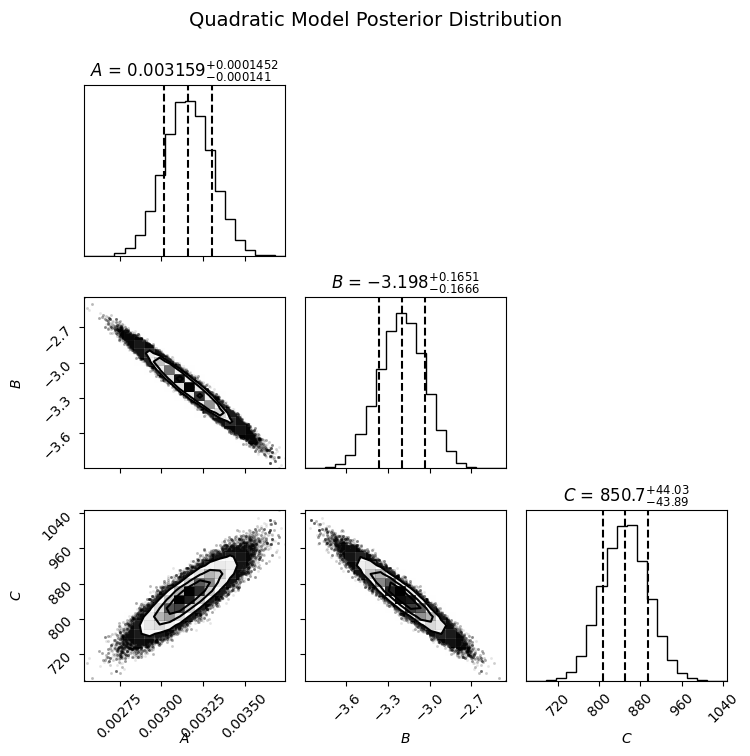

Posterior Median Estimates:
  $A$             = 0.00315862 ± 0.000143652
  $B$             = -3.19771 ± 0.166264
  $C$             = 850.739 ± 43.9857


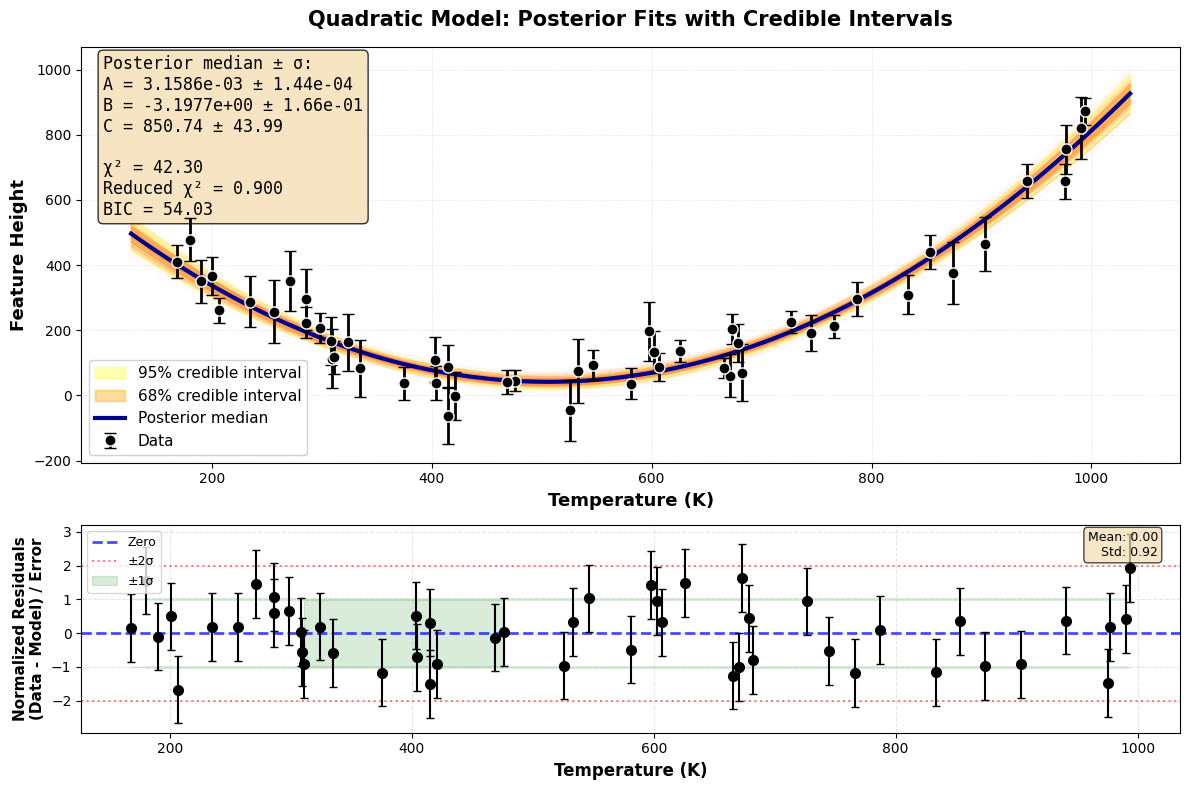

✓ Including x uncertainties (mean xerr = 12.4 K)
  Mean scaled xerr = 0.0125

Running burn-in (500 steps)...


100%|██████████| 500/500 [00:01<00:00, 316.94it/s]


Running production (3000 steps)...


100%|██████████| 3000/3000 [00:08<00:00, 348.34it/s]



✓ Sampling complete!
Autocorrelation time: [8.88517985 8.84496599]
Effective samples: 21609
DIAGNOSTIC: Linear Model
  B: 4.073159e-01 ± 3.326919e-02
  C: -4.137820e+00 ± 2.007293e+01
  Any NaN: False
  Any Inf: False
  Mean residual: 24.88 ± 191.73

Quality Assessment:
  ⚠️  Reduced χ² > 2.0: Poor fit or errors underestimated
  ✓ Model produces varying predictions


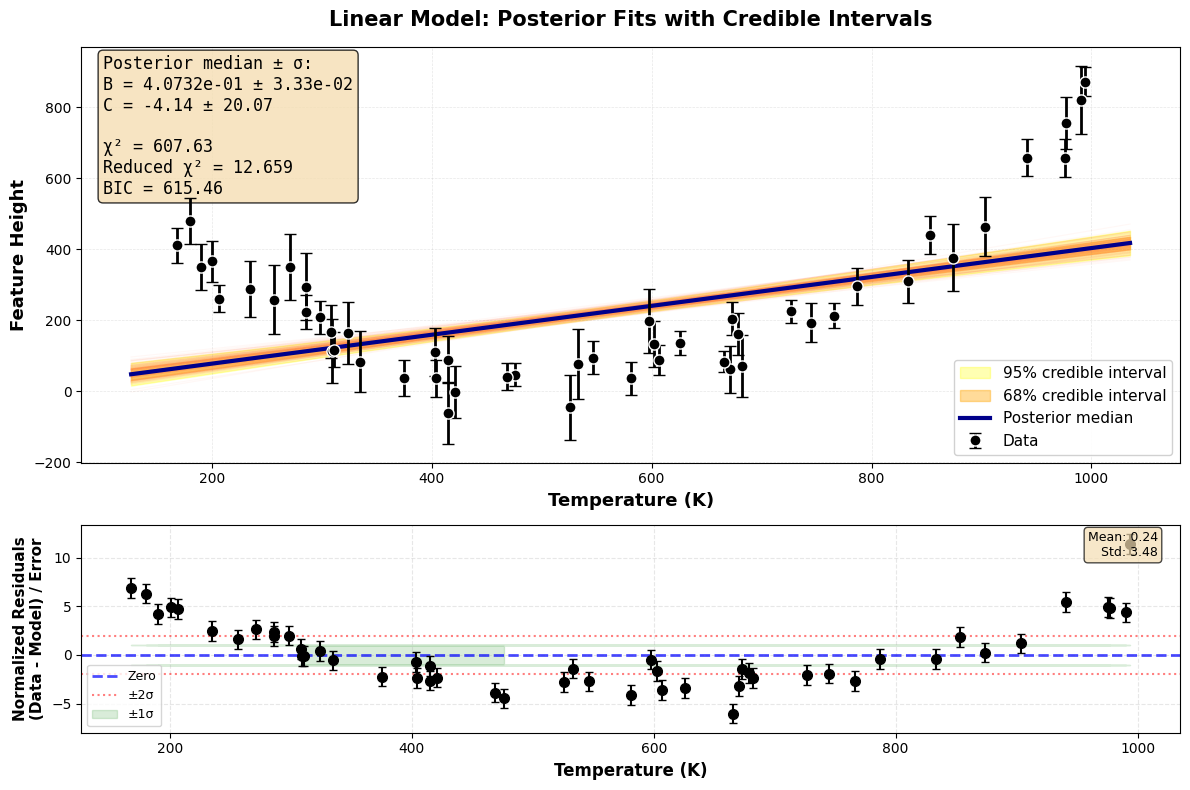

MODEL COMPARISON RESULTS

Bayesian Information Criterion:
  Linear:    BIC = 1116.86
  Quadratic: BIC = 555.44
  ΔBIC (quad - lin) = -561.42

Interpretation: Very strong evidence for more complex model

Goodness of Fit:
  Linear:    χ² = 607.63,  χ²_red = 12.659
  Quadratic: χ² = 42.30, χ²_red = 0.900


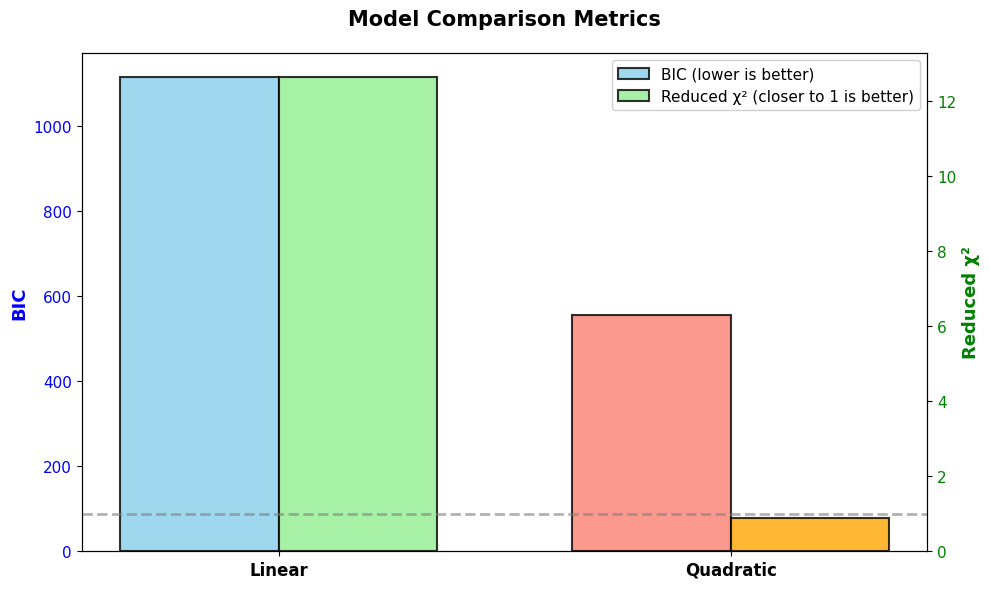


CONSTRAINING POWER ANALYSIS

Pivot temperature: 538.0 K
(Points far from pivot with low errors constrain parameters most)

TOP 5 CONSTRAINING POINTS - LINEAR SLOPE
-------------------------------------------------------
  Rank   T (K)      yerr       Power        Dist from pivot
-------------------------------------------------------
  1      993.8      41.285     1.219e+02    455.9 K
  2      206.6      38.391     7.450e+01    331.4 K
  3      975.5      53.633     6.656e+01    437.6 K
  4      941.1      51.061     6.234e+01    403.2 K
  5      167.9      50.283     5.416e+01    370.0 K

TOP 5 CONSTRAINING POINTS - QUADRATIC CURVATURE
-------------------------------------------------------
  Rank   T (K)      yerr       Power        Dist from pivot
-------------------------------------------------------
  1      993.8      41.285     2.534e+07    455.9 K
  2      975.5      53.633     1.275e+07    437.6 K
  3      941.1      51.061     1.013e+07    403.2 K
  4      206.6      38.391

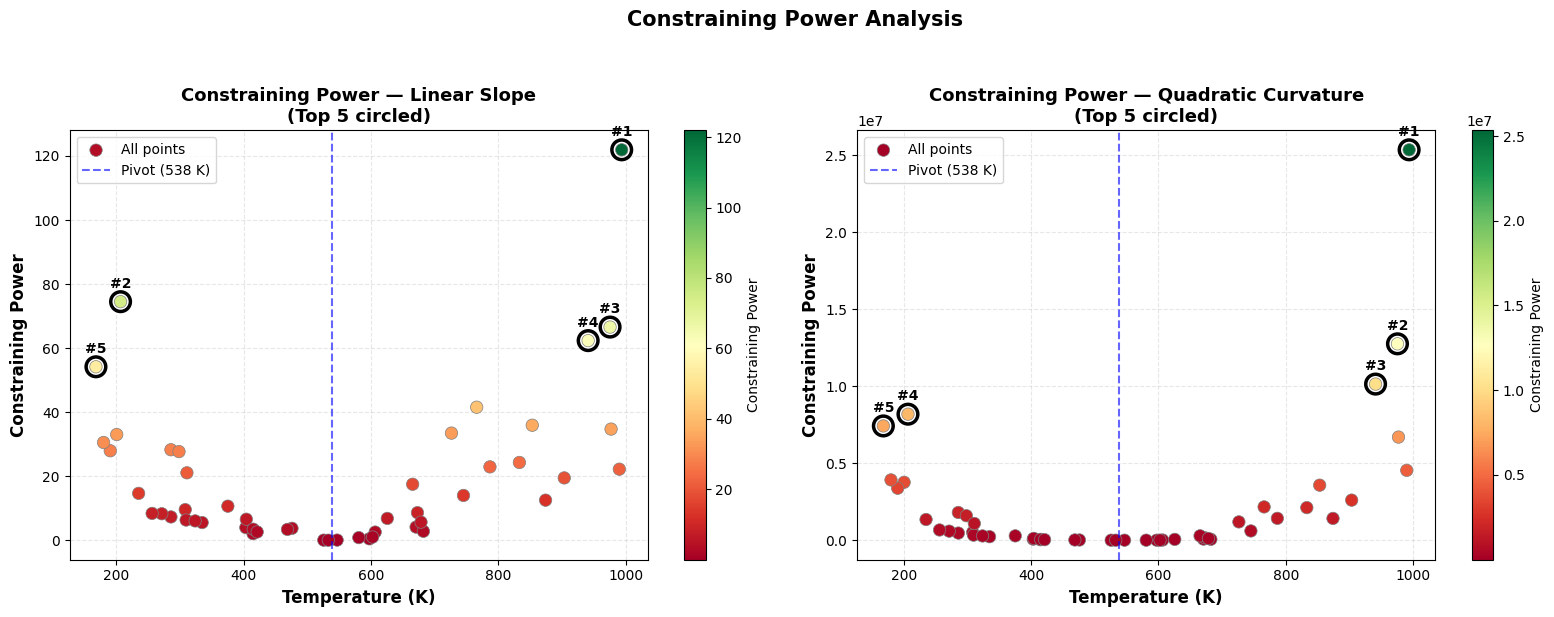

FINAL SUMMARY
Quadratic model reduced χ²: 0.900
Linear model reduced χ²: 12.659
ΔBIC (quad - lin): -561.42
Interpretation: Very strong evidence for more complex model

✓ Quadratic model is statistically preferred!


In [59]:
def generate_test_data(n_points=50, seed=42):
    """
    Generate synthetic quadratic data for testing.
    y = A*T^2 + B*T + C + noise
    """
    np.random.seed(seed)
    
    # TRUE MODEL PARAMETERS
    A_true = 3e-3
    B_true = -3.0
    C_true = 800.0
    
    # Generate temperatures
    T_eq = np.random.uniform(150, 1020, n_points)
    T_eq_err = np.random.uniform(5, 20, n_points)  # Not used in fitting but could be added as uncertainty on T_eq if desired
    # Generate feature heights with noise
    y_true = A_true * T_eq**2 + B_true * T_eq + C_true
    feature_height_err = np.random.uniform(30, 100, n_points)
    feature_height = y_true + np.random.normal(0, feature_height_err)
    
    # Create DataFrame
    data = pd.DataFrame({
        'Equilibrium_Temperature': T_eq,
        'Uncertainty_on_Equilibrium_Temperature': T_eq_err,
        'Feature_Height': feature_height,
        'Uncertainty_on_Feature_Height': feature_height_err
    })
    
    print("=" * 60)
    print("TRUE MODEL PARAMETERS")
    print("=" * 60)
    print(f"A (curvature) = {A_true:.6e}")
    print(f"B (linear)    = {B_true:.6f}")
    print(f"C (offset)    = {C_true:.2f}")
    print(f"Mean uncertainty: {feature_height_err.mean():.2f} ppm")
    print(f"Signal-to-noise ratio: {np.mean(y_true) / np.mean(feature_height_err):.1f}")
    
    return data, A_true, B_true, C_true

data, A_true, B_true, C_true = generate_test_data(n_points=50, seed=42)

stats = Statistics(nwalkers=64, use_parallel=False)
stats.run_all_analysis(data.values)


